# NF-Injections Conditional in low dimensions

Learn the density of parameters in GWTC-4 data, conditioned on some detection probability (FAR).

### Imports

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.special import logit, expit, logsumexp
from scipy.interpolate import interp1d

from astropy.cosmology import FlatLambdaCDM, z_at_value
import astropy.constants as constants
import astropy.units as u

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import corner

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import optax
import equinox as eqx

# FlowJAX (new API)
from flowjax.flows import masked_autoregressive_flow
from flowjax.distributions import Normal

from pathlib import Path

import seaborn as sns
from tqdm import tqdm, trange

import utils as ut


import matplotlib as mpl
mpl.rcParams["text.usetex"] = False

# silence unnecessary warnings about some specific model not being available (shouldn't hurt performance according to ChatGPT)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
jax.config.update('jax_enable_x64', True)

/home/j/Julius.Gassert/.conda/envs/jax/lib/python3.14/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
import os
import socket
print(f"Hostname: {socket.gethostname()}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES')}")
!nvidia-smi

Hostname: kng-cl-nv01.hpc.physik.uni-muenchen.de
CUDA_VISIBLE_DEVICES: 0
Mon Feb 23 15:55:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.211.01             Driver Version: 570.211.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:25:00.0 Off |                    0 |
|  0%   28C    P8             25W /  300W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        

In [3]:
jax.devices()

[CudaDevice(id=0)]

In [16]:
# load injection data
def read_data(file: str, gwtc_version: int) -> pd.DataFrame:
    # Load
    raw_injection_data = h5py.File(file, 'r')
    # injections now called events in gwtc4
    if gwtc_version == 3:
        events = raw_injection_data['injections']
        m1_key, m2_key, dist_key, redshift_key = "mass1", "mass2", "distance", "redshift"
    elif gwtc_version == 4:
        events = raw_injection_data["events"]
        m1_key, m2_key, dist_key, redshift_key = "mass1_detector", "mass2_detector", "luminosity_distance", "z"
    print("Data length:", len(events))

    # Read injection parameters
    injectionData = pd.DataFrame()
    injectionData['m1_detector'] = np.array(events[m1_key][()], dtype='float64')
    injectionData['m2_detector'] = np.array(events[m2_key][()], dtype='float64')
    injectionData['luminosity_distance'] = events[dist_key][()]/1000.  # Convert from Mpc to Gpc
    injectionData['cos_inclination'] = np.cos(events['inclination'])
    injectionData['right_ascension'] = events['right_ascension']
    injectionData['cos_right_ascension'] = np.cos(events['right_ascension'])
    injectionData['declination'] = events['declination']
    injectionData['polarization'] = events['polarization']
    injectionData['cos_polarization'] = np.cos(events['polarization'])
    injectionData['redshift'] = events[redshift_key][()]

    # add source-frame quantities
    injectionData["m1_source"] = injectionData['m1_detector'] / (1 + injectionData['redshift'])
    injectionData["m2_source"] = injectionData['m2_detector'] / (1 + injectionData['redshift'])
    
    # Some derived mass parameters
    injectionData['q'] = injectionData.m2_detector/injectionData.m1_detector
    injectionData['eta'] = injectionData.m1_detector*injectionData.m2_detector/(injectionData.m1_detector+injectionData.m2_detector)**2
    injectionData['chirp_mass_detector'] = injectionData.eta**(3./5.)*(injectionData.m1_detector+injectionData.m2_detector)
    injectionData['total_mass_detector'] = (injectionData.m1_detector+injectionData.m2_detector)

    # And some derived spin parameters
    s1x = np.array(events['spin1x'])
    s1y = np.array(events['spin1y'])
    s1z = np.array(events['spin1z'])
    s2x = np.array(events['spin2x'])
    s2y = np.array(events['spin2y'])
    s2z = np.array(events['spin2z'])
    injectionData['s1x'] = s1x
    injectionData['s1y'] = s1y
    injectionData['s1z'] = s1z
    injectionData['s2x'] = s2x
    injectionData['s2y'] = s2y
    injectionData['s2z'] = s2z
    injectionData['a1'] = np.sqrt(s1x**2 + s1y**2 + s1z**2)
    injectionData['a2'] = np.sqrt(s2x**2 + s2y**2 + s2z**2)
    injectionData['cost1'] = s1z/injectionData.a1
    injectionData['cost2'] = s2z/injectionData.a2
    injectionData['Xeff'] = (s1z + injectionData.q*s2z)/(1.+injectionData.q)
    injectionData['Xdiff'] = (s1z - injectionData.q*s2z)/(1.+injectionData.q)

    sint1 = np.sqrt(1-injectionData.cost1**2)
    sint2 = np.sqrt(1-injectionData.cost2**2)

    injectionData['cos_phi1'] = (s1x / (injectionData.a1*sint1))
    injectionData['cos_phi2'] = (s2x / (injectionData.a2*sint2))

    injectionData["phi1"] = np.arccos(injectionData['cos_phi1'])
    injectionData["phi2"] = np.arccos(injectionData['cos_phi2'])
    # injectionData['Xp_gen'] = generalized_Xp(s1x, s1y, s2x,  s2y, injectionData.q)

    # transforming data for NF (making it nearly Gaussian or similarly well distributed)
    injectionData['sinusoidal_right_ascension'] = np.arccos(1 - injectionData.right_ascension / np.pi)
    injectionData['sinusoidal_polarization'] = np.arccos(1 - 2*injectionData.polarization / np.pi)

    injectionData["t1"] = np.arccos(injectionData.cost1)
    injectionData["t2"] = np.arccos(injectionData.cost2)

    # injectionData["sinusoidal_phi1"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi1) / np.pi)
    # injectionData["sinusoidal_phi2"] = np.arccos(1 - 2 * np.arccos(injectionData.cos_phi2) / np.pi)
    
    if gwtc_version == 4:
        #changed in GWTC4
        far_min = np.min([events['%s_far'%search][:] for search in raw_injection_data.attrs['searches']], axis=0)

        """injectionData['p_draw'] = np.exp(raw_injection_data['lnpdraw_mass1_source_mass2_source_redshift_spin1x_spin1y_spin1z_spin2x_spin2y_spin2z'][:])/(1+injectionData['redshift'])**2/ddL_of_z(injectionData['redshift'],injectionData['luminosity_distance'],H0cosmo)
        T = (raw_injection_data.attrs['total_analysis_time'])/(3600.0*24.0*365.25) 
        injectionData['p_draw'] /= T
        
        
        injectionData['p_draw'] /= injectionData['weights'] # ädont think i should do this here"""

    # ifar_max = np.max([events['%s_ifar'%search][:] for search in raw_injection_data.attrs['searches']], axis=0)
    # injectionData['ifar_max'] = ifar_max
    injectionData['weights'] = events['weights'][()]
    injectionData['far_min'] = far_min
    injectionData['detected'] = np.where(far_min < 1, 1, 0)
    print("Number of detected injections:", np.sum(injectionData['detected']))

    meta = dict(raw_injection_data.attrs.items())

    return injectionData, meta

### Load File

In [17]:
# fname = Path("/hildafs/home/jgassert/hildafs_phy220048p_symlink/share/GWTC-PESamples/posterior_samples/O4/GWTC-4_bbh_posterior_samples_seed1.h5")
# fname = Path("/project/ls-gruen/users/julius.gassert/data/GWTC-4_bbh_posterior_samples_seed1.h5")
fname = Path("/project/ls-gruen/users/julius.gassert/data/samples-rpo4a_v2_20250503133839UTC-1366933504-23846400.hdf")

# col_names = ['a1', 'a2', 'chieff', 'dL', 'dec', 'm1det', 'm2det', 'ra', 'z']

f = h5py.File(fname, "r")
f.keys()

<KeysViewHDF5 ['events']>

In [18]:
data_df, meta = read_data(fname, 4)

# sel = data_df["detected"] == True
# data_df = data_df.loc[sel]
data_df

Data length: 1499244
Number of detected injections: 476406


,m1_detector,m2_detector,luminosity_distance,cos_inclination,right_ascension,cos_right_ascension,declination,polarization,cos_polarization,redshift,...,cos_phi2,phi1,phi2,sinusoidal_right_ascension,sinusoidal_polarization,t1,t2,weights,far_min,detected
0,87.680089,56.912638,4.007806,-0.002645,5.002674,0.286225,-0.254790,0.614705,0.816944,0.651001,...,-0.419573,1.980028,2.003771,2.204832,0.916417,1.346254,0.404648,0.804290,inf,0
1,54.408109,49.680587,2.381053,-0.489065,0.409010,0.917515,-0.917783,0.058546,0.998287,0.421988,...,-0.800620,2.311274,2.499126,0.515983,0.273882,0.957176,0.501396,0.804290,inf,0
2,51.668975,20.366343,2.690371,0.910738,5.263240,0.523413,-0.698737,2.663313,-0.887788,0.467684,...,0.999102,2.619596,0.042391,2.312224,2.339936,2.234633,0.852469,0.804290,inf,0
3,102.782254,86.531760,3.907749,0.868521,3.848270,-0.760524,-0.599299,0.296581,0.956341,0.637607,...,0.751952,0.858756,0.719778,1.797680,0.624611,1.671130,0.662741,0.804290,inf,0
4,40.381354,34.546820,3.611020,0.871280,2.204904,-0.592459,1.053326,2.647054,-0.880188,0.597428,...,0.894287,2.179491,0.463960,1.268035,2.325630,1.446252,1.558749,0.804290,inf,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499239,42.069507,27.655349,1.836552,-0.788572,5.592748,0.770968,1.044990,0.352504,0.938511,0.338223,...,-0.963358,1.943266,2.870050,2.465825,0.683149,1.800141,2.533089,1.130915,inf,0
1499240,141.587869,108.244782,9.694232,-0.826559,0.428992,0.909386,1.191597,0.822922,0.680082,1.334967,...,0.366296,0.813973,1.195771,0.528732,1.074569,1.598731,1.991064,1.130915,inf,0
1499241,101.335786,100.248667,4.904618,0.857559,3.778430,-0.803980,-0.948454,1.955454,-0.375242,0.768044,...,0.645054,2.838642,0.869703,1.774923,1.818193,0.509533,2.018699,1.130915,inf,0
1499242,4.701713,3.397398,0.335602,-0.448865,0.864340,0.649142,0.470035,0.662202,0.788640,0.072109,...,0.967612,0.135808,0.255205,0.759948,0.953995,2.353646,0.194585,1.130915,inf,0


In [19]:
meta

{'date': np.bytes_(b'13:38:22 UTC Sat 03 May 2025'),
 'gps_end': np.int64(1390779904),
 'gps_start': np.int64(1366933504),
 'num_accepted': np.int64(3974400),
 'searches': array(['cwb-bbh', 'gstlal', 'mbta', 'pycbc'], dtype=object),
 'total_analysis_time': np.float64(23846400.0),
 'total_analysis_time_1ifo': np.float64(17051365.0),
 'total_analysis_time_2ifo': np.float64(10947642.0),
 'total_generated': np.int64(433157717)}

In [20]:
N_injections = meta["total_generated"]

In [21]:
data_df["far_min"].min(), data_df["far_min"].max()

(np.float64(1.2234802261494909e-66), np.float64(inf))

In [22]:
data_df.columns

Index(['m1_detector', 'm2_detector', 'luminosity_distance', 'cos_inclination',
       'right_ascension', 'cos_right_ascension', 'declination', 'polarization',
       'cos_polarization', 'redshift', 'm1_source', 'm2_source', 'q', 'eta',
       'chirp_mass_detector', 'total_mass_detector', 's1x', 's1y', 's1z',
       's2x', 's2y', 's2z', 'a1', 'a2', 'cost1', 'cost2', 'Xeff', 'Xdiff',
       'cos_phi1', 'cos_phi2', 'phi1', 'phi2', 'sinusoidal_right_ascension',
       'sinusoidal_polarization', 't1', 't2', 'weights', 'far_min',
       'detected'],
      dtype='str')

### Prepare the data

FORWARD / INVERSE TRANSFORMS + WHITENING

In [23]:
# Targets with inf values - use strategy appropriate for your data
y_df = pd.DataFrame({"far_min": data_df["far_min"].values})
# 
# Option 1: Clip inf to 99.9th percentile of finite values
# y_data = ut.Data(y_df, cols=["far_min"], handle_inf="clip", inf_clip_percentile=99.9)
#
# Option 2: Drop rows with inf (will also drop corresponding X rows)
y_data = ut.Data(y_df, cols=["far_min"], handle_inf="drop")

"""if "mask" in y_data.cleaning_info:
    data_df_sel = data_df.loc[y_data.cleaning_info["mask"]]
else:
    data_df_sel = data_df"""

# cols = ["m1_detector", "m2_detector", "luminosity_distance", "a1", "a2", "right_ascension", "declination", "cos_inclination", "polarization", "cost1", "cost2"]

# data_cols = ["a1"]
data_cols = ["m1_source", "m2_source"]
# transforms = ["log", "log", "log"] + 10*["none"]
X_data = ut.Data(
    data_df,
    cols=data_cols,
    handle_inf="clip",  # Clip outliers
    mask = y_data.cleaning_info["mask"],
    transforms = ["none"]*2,
)
#
# Option 3: Fill inf with a large value
# y_data = Data(y_df, cols=["redshift"], handle_inf="fill", inf_fill_value=1e6)
#
# Check cleaning info
print("Y data cleaning:", y_data.get_cleaning_info())
#
# Create dataset
dataset = ut.Dataset(X=X_data, y=y_data, use_whitened_X=False, use_whitened_y=False)

Dropped 525394 rows with inf/nan values
Y data cleaning: {'n_inf': 525394, 'n_nan': 0, 'n_total_special': 525394, 'strategy': 'drop', 'n_dropped': 525394, 'n_remaining': 973850, 'mask': array([False, False, False, ..., False, False, False], shape=(1499244,))}


In [24]:
# check that transform + inverse transform is identity
reverse_transform_data = X_data.inverse_transform(X_data.samples_transformed)
np.allclose(reverse_transform_data, X_data.samples, rtol=1e-6, atol=1e-6) # standard atol is slightly lower, but this is fine

True

In [25]:
# check that transform + whiten + inverse whiten + inverse transform is identity
x_white = X_data.whitened_data
x_rec = X_data.inverse_whiten_data(x_white)
np.allclose(x_rec, X_data.samples, rtol=9.9e-2, atol=1e-3), np.count_nonzero(np.isclose(x_rec, X_data.samples,rtol=1e-4, atol=1e-5))

(True, np.int64(1947700))

In [26]:
# check transformations are good on Dataset class
print("Data Shape", dataset.X_data.get_shape(), "makes", dataset.X_data.get_shape()[0]*dataset.X_data.get_shape()[1], "entries")
X_recovered_dataset, y_recovered_dataset = dataset.to_original_space(dataset.X_data.whitened_data, dataset.y_data.whitened_data)
np.count_nonzero(np.isclose(X_data.data_df.to_numpy(), np.array(X_recovered_dataset),rtol=1e-2, atol=1e-3))

Data Shape (973850, 2) makes 1947700 entries


np.int64(0)

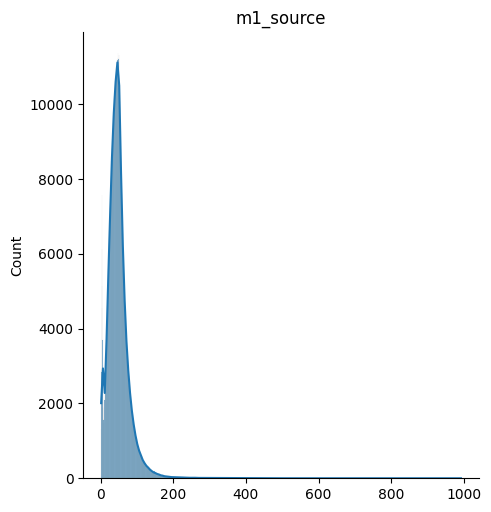

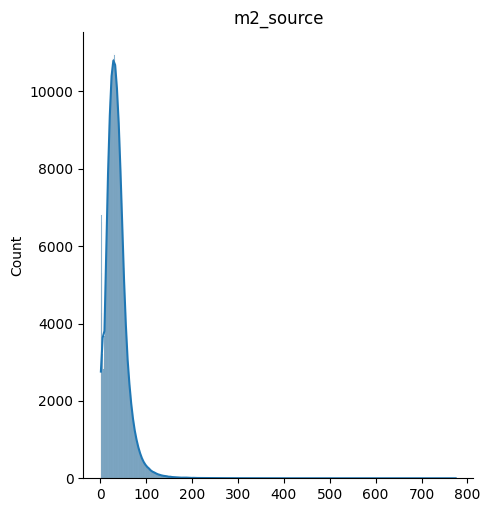

In [27]:
for i in range(dataset.X_data.whitened_data.shape[1]):
    # continue
    sns.displot(np.array(dataset.X[:, i]), kde=True)
    plt.title(dataset.X_data.data_df.columns[i])
    plt.show()

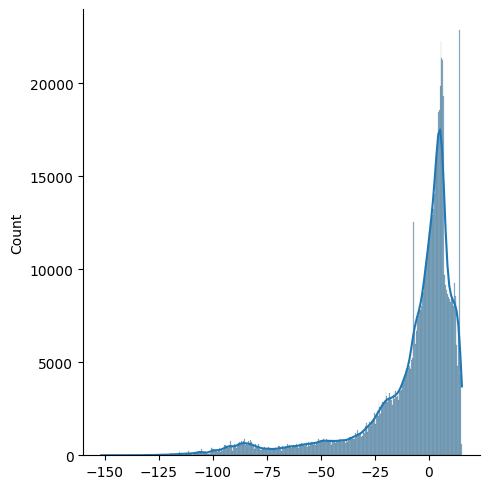

In [28]:
for i in range(dataset.y_data.whitened_data.shape[1]):
    # continue
    sns.displot(np.array(dataset.y[:, i]), kde=True)
    plt.show()

In [29]:
y_data.transformations

['log']

### Build Flowjax MAF

In [30]:
key_val = 0
key = jax.random.key(key_val)

train_dataset, val_dataset, train_idx, val_idx = dataset.split(key, train_frac=0.8)

config_MAF = {
    "base_dist": "Normal",
    "data_dim": train_dataset.X.shape[1],
    "key": key_val,
    "cond_dim": train_dataset.y.shape[1],  
    "flow_layers": 6,
    "nn_width": 96,
    "nn_depth": 4
}

config = config_MAF
config["type"] = "MAF"

flow = ut.create_flow_from_config(config)

In [ ]:
flow, meta = ut.train_flow(flow, train_dataset, val_dataset, patience = 25, batch_size = 4096)

Training:  13%|█▎        | 130/1000 [10:13<1:07:56,  4.69s/it, best_val=7.7843, patience=3, train=7.7970, val=7.7875] 

In [ ]:
train_losses = meta["train_losses"]
val_losses = meta["val_losses"]

sns.lineplot(x=np.arange(1, len(train_losses) + 1), y=train_losses, label = "mean train loss")
sns.lineplot(x=np.arange(1, len(val_losses) + 1), y=val_losses, label = "mean val loss")
plt.vlines(x = meta["best_epoch"], ymin = min(val_losses)-1, ymax = max(val_losses), color = "red", linestyle = "--", label = "best val epoch")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss over Epochs")
# plt.yscale("log")
plt.ylim(min(val_losses + train_losses)-.1, max(val_losses))
plt.show()

In [ ]:
threshold_far = 1 # threshold for the FAR_MIN

In [ ]:
data_sel = X_data.full_data_df["far_min"] < threshold_far
np.sum(data_sel)

In [ ]:
y_orig_batch = jnp.array(X_data.full_data_df["far_min"].values[data_sel]) # jnp.array(rng.uniform(low = 1, high = 100, size = np.sum(data_sel)))
y_orig_batch = y_orig_batch[:, None]

y0_transformed = dataset.y_data.forward_transform(y_orig_batch)

y0_white, _, _ = dataset.y_data.whiten_data(y_orig_batch)
y0_white.shape, y0_white.min(), y0_white.max(), y0_white.mean()

In [ ]:
print("Reminder to check what you did the conditioning data: no transformation, transformation, whitening, transformation + whitening?")

In [ ]:
cond = y0_transformed
S = 1
# 4. sample in whitened x-space
z_key, key = jax.random.split(key)
x_white_samples = flow.sample(z_key, (S,), condition=cond)  # (S, dx)

print(x_white_samples.shape, cond.shape)
x_mean_samples = x_white_samples.mean(axis = 0) # dont even need to do this, because the output now is only 1d per generation anyway
print(x_mean_samples.shape)

# 5. map samples back to original x-space
x_samples_orig_space = dataset.to_original_space_X(x_mean_samples)

In [ ]:
# labels = [r"$m_{1,\rm det}$", r"$m_{2,\rm det}$", r"$D_L$", r"$\chi_\mathrm{eff}$", r"$\alpha$", r"$\delta$"]
ranges = [(0, 200), (0, 200)]
# ranges = [(0, 1)]
# data_cols = ["m1_detector", "m2_detector", "luminosity_distance", "a1", "a2", "cos_inclination", "polarization", "cost1", "cost2", "right_ascension", "declination"]

labels = X_data.data_df.columns

data_samples = X_data.data_df[data_sel]

fig = corner.corner(
    data_samples,
    labels=labels,
    color="C0",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    label_kwargs={"fontsize": 14},
    range = ranges,
)

corner.corner(
    np.array(x_samples_orig_space),
    fig=fig,
    color="C3",
    bins=40,
    plot_datapoints=False,
    smooth=1.0,
    range = ranges,
)


legend_elements = [
    Line2D([0], [0], color="C0", lw=2, label=f"Injection Data (FAR < 1)"),
    Line2D([0], [0], color="C3", lw=2, label="Conditional (FAR < 1) NF samples"),
    Line2D([0], [0], color="none", lw=0, label=f"{np.sum(data_sel)} samples each"),
]

fig.legend(
    handles=legend_elements,
    loc="upper right",
    fontsize=20,
    frameon=True,
    handlelength = 2,
)

plt.suptitle("Conditional NF: Injection Posteriors vs. MAF", fontsize=42)
# plt.savefig("plots/CNF_InjectionsVSMAF_1FAR.pdf")
plt.show()

In [4]:
filename_flow = "trained_flows/CNF_Injections/CNF.npz"

In [39]:
# config["trained_columns"] = train_dataset.X_data.data_df.columns.to_list()
# ut.save_flow(filename_flow, flow, config)
# also need to save the data (transformations)
# train_dataset.save("trained_flows/CNF_Injections/training_dataset/", save_data = True)
# val_dataset.save("trained_flows/CNF_Injections/val_dataset/", save_data = True)
# dataset.save("trained_flows/CNF_Injections/dataset/", save_data = True)
# X_data.save("trained_flows/CNF_Injections/X")
# y_data.save("trained_flows/CNF_Injections/y")

Data and transformations saved to trained_flows/CNF_Injections/dataset/X
Data and transformations saved to trained_flows/CNF_Injections/dataset/y
Dataset configuration saved to trained_flows/CNF_Injections/dataset


In [5]:
# loaded_flow, loaded_config = ut.load_flow(filename_flow, ut.create_flow_from_config)
# dataset = ut.Dataset.from_saved("trained_flows/CNF_Injections/dataset/")
# train_dataset, val_dataset = dataset.get_split_datasets()

E0211 21:23:51.805826     655 ptx_compiler_helpers.cc:132] *** WARNING *** Invoking ptxas with version 12.6.20, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.


### Quantitative Evaluation: Summary Statistics

Let's compare the descriptive statistics (mean, standard deviation, and correlations) of the original samples and the flow-generated samples. A good fit should show similar statistics between the two sets.

In [ ]:
import pandas as pd

# Convert to pandas DataFrames for easy summary statistics
df_samples = dataset.X_data.data_df
df_rec = pd.DataFrame(x_rec, columns=labels)

print("--- Original Samples Summary Statistics ---")
display(df_samples.describe())

print("\n--- Flow-Generated Samples Summary Statistics ---")
display(df_rec.describe())

print("\n--- Original Samples Correlation Matrix ---")
display(df_samples.corr())

print("\n--- Flow-Generated Samples Correlation Matrix ---")
display(df_rec.corr())

### Quantitative Evaluation: Kolmogorov-Smirnov (KS) Test

The Kolmogorov-Smirnov test is a non-parametric test that compares the empirical cumulative distribution functions (ECDFs) of two samples. We'll perform it for each 1D marginal distribution to check if the original and flow-generated samples come from the same underlying distribution. A small p-value (e.g., < 0.05) would suggest that the distributions are statistically significantly different.

In [ ]:
from scipy import stats

print("--- Kolmogorov-Smirnov Test for 1D Marginals ---")
print("H0: The two samples are drawn from the same continuous distribution.")
print("If p-value is small (e.g., < 0.05), we reject H0, meaning distributions are likely different.")
dowsample = 1
for i, label in enumerate(labels):
    stat, p_value = stats.kstest(np.array(data_samples.to_numpy()[::dowsample, i]), x_rec[::dowsample, i])
    print(f"\nParameter: {label}")
    print(f"  KS Statistic: {stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  -> Distributions are statistically significantly different (reject H0)")
    else:
        print("  -> Distributions are not statistically significantly different (fail to reject H0)")

In [36]:
# Assumed constants
H0cosmo = 67.9 # constants from https://dcc.ligo.org/public/0170/P2000318/011/o3b_catalog.pdf
Om0cosmo = 0.3065
cosmo = FlatLambdaCDM(H0=H0cosmo * u.km / u.s / u.Mpc, Om0=Om0cosmo)
speed_of_light = constants.c.to(u.km / u.s).value

def ddL_of_z(z, dL, H0):
    return dL / (1 + z) + speed_of_light * (1 + z) / (H0 * cosmo.efunc(z))

N_eval = 1000000
mass_grid = np.linspace(1, 1000, N_eval)
spin_grid = np.linspace(0, 1, N_eval)
z_grid = np.linspace(0, 3, N_eval)
dVdz_grid = cosmo.differential_comoving_volume(z_grid).to(u.Gpc**3 / u.sr).value * 4 * np.pi

def primary_mass_pdf_interp(m1, min_m1=1.0, max_m1=1000.0):

    m = mass_grid.astype(float)
    logm = np.log(m)

    log_pdf = np.full_like(m, -np.inf)  # log(0)

    # --- piecewise definitions in log-space ---
    # [1, 3): flat
    sel = (m >= 1) & (m < 3)
    log_pdf[sel] = 0.0

    # [3, 8): (m/3)^(-4)
    sel = (m >= 3) & (m < 8)
    log_pdf[sel] = -4.0 * (logm[sel] - np.log(3.0))

    # [8, 50): continuity enforced explicitly
    sel = (m >= 8) & (m < 50)
    log_norm = -4.0 * (np.log(8.0) - np.log(3.0))
    log_pdf[sel] = log_norm - 1.0 * (logm[sel] - np.log(8.0))

    # [50, 200)
    sel = (m >= 50) & (m < 200)
    log_norm += -1.0 * (np.log(50.0) - np.log(8.0))
    log_pdf[sel] = log_norm - 4.0 * (logm[sel] - np.log(50.0))

    # [200, 1000)
    sel = (m >= 200) & (m < 1000)
    log_norm += -4.0 * (np.log(200.0) - np.log(50.0))
    log_pdf[sel] = log_norm - 1.0 * (logm[sel] - np.log(200.0))

    # Outside allowed range
    log_pdf[(m < min_m1) | (m > max_m1)] = -np.inf

    # --- exponentiate safely ---
    pdf = np.exp(log_pdf)

    # --- normalize robustly ---
    norm = np.trapezoid(pdf, m)
    if norm > 0:
        pdf /= norm

    # --- interpolate ---
    return interp1d(
        m, pdf,
        bounds_error=False,
        fill_value=0.0,
        assume_sorted=True
    )(m1)

def primary_mass_pdf(m1, min_m1=1.0, max_m1=1000.0):

    m = np.asarray(m1, dtype=float)
    logm = np.log(m, where=(m > 0), out=np.full_like(m, -np.inf))

    log_pdf = np.full_like(m, -np.inf)  # log(0)

    # --- piecewise definition in log-space ---

    # [1, 3): flat
    sel = (m >= 1) & (m < 3)
    log_pdf[sel] = 0.0

    # [3, 8): (m/3)^(-4)
    sel = (m >= 3) & (m < 8)
    log_pdf[sel] = -4.0 * (logm[sel] - np.log(3.0))

    # [8, 50)
    sel = (m >= 8) & (m < 50)
    log_norm = -4.0 * (np.log(8.0) - np.log(3.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(8.0))

    # [50, 200)
    sel = (m >= 50) & (m < 200)
    log_norm += -1.0 * (np.log(50.0) - np.log(8.0))
    log_pdf[sel] = log_norm - 4.0 * (logm[sel] - np.log(50.0))

    # [200, 1000)
    sel = (m >= 200) & (m < 1000)
    log_norm += -4.0 * (np.log(200.0) - np.log(50.0))
    log_pdf[sel] = log_norm - (logm[sel] - np.log(200.0))

    # Outside bounds
    log_pdf[(m < min_m1) | (m > max_m1)] = -np.inf

    # --- exponentiate safely ---
    pdf = np.exp(log_pdf)

    # --- robust normalization ---
    # Sort for trapezoid stability
    idx = np.argsort(m)
    m_sorted = m[idx]
    pdf_sorted = pdf[idx]

    norm = np.trapezoid(pdf_sorted, m_sorted)
    if norm > 0:
        pdf /= norm

    return pdf


def secondary_mass_pdf(m2, m1, min_m2 = 1):

    pm2 = 2*m2 / (m1**2 - 1)
    support = (m2 >= min_m2) & (m2 <= m1)
    # should be properly normalized already I realize
    return np.where(support, pm2, 0.0)

def spin_pdf(s):

    ps = np.exp(-2*s**2)

    idx = np.argsort(s)
    s_sorted = s[idx]
    pdf_sorted = ps[idx]
    
    norm = np.trapezoid(pdf_sorted, s_sorted)
    if norm > 0:
        ps /= norm

    return ps

def cos_tilts_pdf(tilt):
    """Includes Jacobian to go from tilt to cos_tilt"""
    cos_tilt = np.cos(tilt)
    # should be normalized given the definition
    pcost = (0.3 * ((1+cos_tilt)**3)/4 + 0.35)*np.sin(tilt)  # last summand is 0.7*1/2
    return pcost

def tilts_pdf(tilt):
    # should be normalized given the definition
    pcost = (0.3 * ((1+tilt)**3)/4 + 0.35)  # last summand is 0.7*1/2
    return pcost

def redshift_pdf(z, z_grid, dVdz_grid):
    num_grid = dVdz_grid
    den = np.trapezoid(num_grid, z_grid)
    num_grid /= den
    
    return interp1d(z_grid, num_grid, fill_value = 0, bounds_error = False)(z)

In [37]:
def calc_p_model(data: pd.DataFrame, redshifts: np.ndarray |None = None) -> np.ndarray:
    """Calculates the p(theta) for GWTC and specific 13 parameters

    Args:
        data: DataFrame containing the parameters.

    Returns:
        Model probabilites.
    """

    if "redshift" not in data.columns and redshifts is None:
        data["redshift"] = z_at_value(cosmo.luminosity_distance, data["luminosity_distance"].to_numpy()*u.Mpc, zmax = 3).value
    elif redshifts is not None:
        data["redshift"] = redshifts
        
    # data["m1_source"] = data["m1_detector"] / (1+data["redshift"])
    # data["m2_source"] = data["m2_detector"] / (1+data["redshift"])

    pm1 = primary_mass_pdf(data["m1_source"])
    pm2 = secondary_mass_pdf(data["m2_source"], data["m1_source"])
    # pa1 = spin_pdf(data["a1"].to_numpy())
    # pa2 = spin_pdf(data["a2"].to_numpy())
    # pt1 = cos_tilts_pdf(data["t1"])
    # pt2 = cos_tilts_pdf(data["t2"])
    # pz = redshift_pdf(data["redshift"], z_grid, dVdz_grid)

    # Make sure data is correctly drawn from the below pdfs (follows GWTC-4)

    # pphi1 = np.ones_like(data["phi1"]) / (2*np.pi) # uniform in [0, 2pi]
    # pphi2 = np.ones_like(data["phi2"]) / (2*np.pi) # uniform in [0, 2pi]
    # pra = np.ones_like(data["right_ascension"]) / (2*np.pi) # uniform in [0, 2pi]
    # ppol = np.ones_like(data["polarization"]) / np.pi # uniform in [0, pi]
    # pdec = 1 / 2 # uniform in sin(delta) [-1, 1]
    # pinc = 1 / 2 # uniform in cos(inc) [-1, 1]

    return pm1*pm2 # *pa1*pa2 # *pz*pt1*pt2*pphi1*pphi2*pra*pdec*ppol*pinc

In [38]:
from functools import partial
@partial(jax.jit, static_argnames=['transformations'])
def calc_jacobians_transform_cnf_jit(theta, transformations):
    """
    JAX-compatible calculation of Jacobian log-determinant.
    
    Args:
        theta: JAX array of shape (N,) containing parameters.
        transformations: Tuple or list of strings defining the transform for each param.
                         Must be marked static for JIT compilation.
    """
    assert len(transformations) == 13, f"length of transformations is {len(transformations)} while it should be 13"

    log_j_sum = 0

    for i, transform in enumerate(transformations):
        param = theta[i]
        if transform == "log":
            term = (jnp.abs(1/param))
        elif transform == "angle_2pi":
            term = jnp.abs(1/param + 1/(2*jnp.pi - param))
        elif transform == "angle_pi":
            term = jnp.abs(1/param + 1/(jnp.pi - param))            
        elif transform == "angle_signed_pi":
            term = jnp.abs((2*jnp.pi) / (jnp.pi**2 - param**2))
        else:
            term = 1 # is 0 in log
        log_j = jnp.log(term)
        log_j_sum += log_j
    return log_j_sum


def calc_jacobians_transform_cnf(theta_pre_transform, transformations):
    J = []
    for param, transform in zip(theta_pre_transform, transformations):
        if transform == "log":
            J.append(np.abs(1/param))
        elif transform == "angle_2pi":
            J.append(np.abs(1/param + 1/(2*np.pi-param)))
        elif transform == "angle_pi":
            J.append(np.abs(1/param + 1/(np.pi-param)))
        elif transform == "angle_signed_pi":
            J.append(np.abs(2*np.pi / (np.pi**2 - param**2)))

    # assert len(J) == 13, f"length of Jacobian is {len(J)} while it should be 13"
    return np.sum(np.log(J))

def calc_jacobians_reparametrization_cnf(data: pd.DataFrame):
    """Reparametrizing the theta that go into pCNF(theta) compared to p(theta) from injections costs Jacobians."""

    J_m1 = 1 + data["redshift"]
    J_m2 = J_m1

    J_s1 = 1
    J_s2 = 1

    J_z = 1/ddL_of_z(data["redshift"], data["luminosity_distance"], cosmo.H0)

    J_inc = 1

    J_pol = 1/(np.sqrt((np.pi - data["polarization"])*data["polarization"]))

    J_t1 = 1/np.abs(np.sin(data["t1"]))
    J_t2 = 1/np.abs(np.sin(data["t2"]))

    J_phi1 = np.abs(np.sin(data["phi1"]))
    J_phi2 = np.abs(np.sin(data["phi2"]))

    J_ra = 1 / np.sqrt((2*np.pi - data["right_ascension"]) * data["right_ascension"])
    J_dec = 1 / (data["declination"]**2) * 1 / np.abs(np.cos(data["declination"]))

    return J_m1*J_m2*J_s1*J_s2*J_z*J_inc*J_pol*J_pol*J_t1*J_t2*J_phi1*J_phi2*J_ra*J_dec

@eqx.filter_jit
def calc_log_pCNF(flow, theta, far):
    theta = jnp.asarray(theta)
    far   = jnp.asarray(far)
    log_probs = flow.log_prob(theta, condition=far)
    return log_probs

"""def calc_pCNF(flow, theta, theta_pre_transform, far, transformations, L):
    log_probs = calc_log_pCNF(flow, theta, far)
    # need to account for all the jacobians...
    log_probs = jsp.special.logsumexp(log_probs) + jnp.log(calc_jacobians_transform_cnf(theta_pre_transform, transformations)) - jnp.sum(jnp.log(jnp.diag(L))) # Jacobians from transformations and whitening
    return jnp.exp(log_probs)"""

'def calc_pCNF(flow, theta, theta_pre_transform, far, transformations, L):\n    log_probs = calc_log_pCNF(flow, theta, far)\n    # need to account for all the jacobians...\n    log_probs = jsp.special.logsumexp(log_probs) + jnp.log(calc_jacobians_transform_cnf(theta_pre_transform, transformations)) - jnp.sum(jnp.log(jnp.diag(L))) # Jacobians from transformations and whitening\n    return jnp.exp(log_probs)'

In [39]:
def calc_p_detection(flow: Transform, val_dataset: ut.Dataset, val_idx, redshifts: np.ndarray |None = None, far_threshold: float = 1) -> np.ndarray:

    # contrary to what the json file says, I did whiten the X data, but not the y (conditioning) data

    theta = jnp.array(val_dataset.X.copy()) # make sure we work on the gw parameters only for the flow
    conditioning = val_dataset.y.copy()

    data = val_dataset.X_data.full_data_df.iloc[val_idx]

    far =  val_dataset.y_data.data_df.to_numpy()[val_idx].squeeze()
    theta_pre_transform = val_dataset.X_data.data_df.to_numpy()[val_idx].squeeze()
    # print(far.shape, theta_pre_transform.shape)
    
    far_sel = far < far_threshold
    N_total = len(far)
    
    print(f"Calculating model for {np.sum(far_sel)} data...")
    data_sel = data.iloc[far_sel]
    # print(data.columns)
    p_model = calc_p_model(data)

    weights = data["weights"].to_numpy()
    assert len(weights) == len(theta), f"Wrong shapes: {weights.shape} and {theta.shape}"

    log_pCNFs = []
    idx = 0
    far_subset = jnp.array(conditioning[far_sel])
    # pCNFs = calc_log_pCNF_many(flow, theta, far_subset)
    for i, data_row in tqdm(enumerate(theta)):
        # pCNFs.append(calc_pCNF(flow, data_row, conditioning[far_sel], val_dataset.X_data.transformations, val_dataset.X_data.L))
        log_pCNFs.append(jsp.special.logsumexp(calc_log_pCNF(flow, data_row, conditioning[far_sel]) + weights[i]))

    log_pCNFs = np.array(log_pCNFs)
    
    return p_model, N_total, log_pCNFs

In [49]:
val_idx = dataset.val_indices
data = val_dataset.X_data.full_data_df.iloc[val_idx]
far =  val_dataset.y_data.data_df.to_numpy()[val_idx].squeeze()
np.sum(far < 1)

np.int64(47987)

In [41]:
# p_model, N, log_pCNFs, log_jacobian_transformations, log_jacobian_whitening = calc_p_detection(loaded_flow, val_dataset, val_idx)
p_model, N, log_pCNFs = calc_p_detection(flow, val_dataset, val_idx)

Calculating model for 47987 data...


97385it [06:53, 235.55it/s]


In [46]:
p_CNFs = np.exp(log_pCNFs) / np.sum(data["weights"])
p_det_nonorm = p_CNFs/p_model

In [50]:
p_det_nonorm.min(), p_det_nonorm.max(), p_det_nonorm.mean(), p_det_nonorm[far < 1].min(), p_det_nonorm[far < 1].max(), p_det_nonorm[far < 1].mean()

(np.float64(9.466489955608119e-08),
 np.float64(2467344.4195131143),
 np.float64(1058.011102043141),
 np.float64(1.2752865554654472e-07),
 np.float64(1821329.4789831962),
 np.float64(1112.9399223433447))

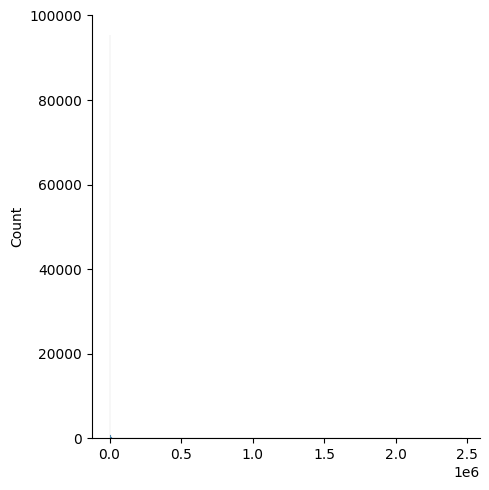

In [48]:
sns.displot(p_det_nonorm)
plt.show()

In [75]:
random_numbers = np.random.uniform(p_det_nonorm.min(), p_det_nonorm.max(), size = p_det_nonorm.shape)
detected = p_det_nonorm > random_numbers
np.sum(detected), random_numbers.min(), random_numbers.max()

(np.int64(52), np.float64(39.81516170220693), np.float64(2467319.021685655))

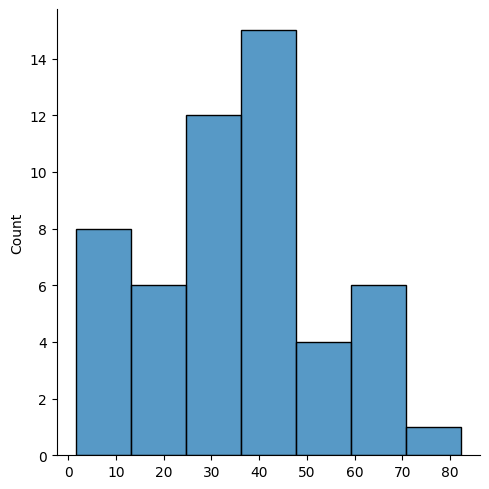

In [76]:
sns.displot(val_dataset.X[detected, 0])

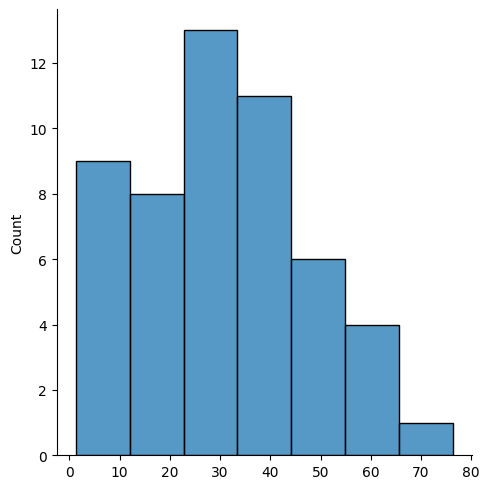

In [77]:
sns.displot(val_dataset.X[detected, 1])


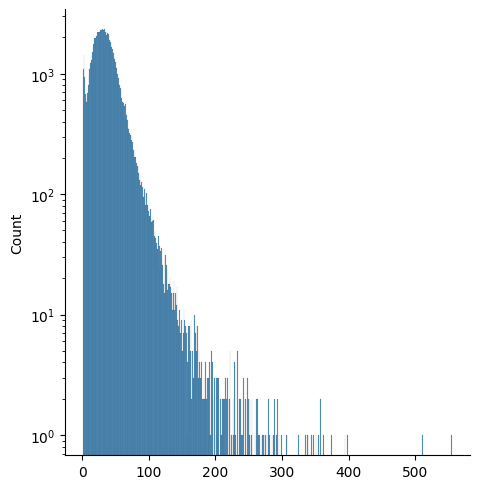

In [67]:
sns.displot(val_dataset.X[:, 1])
plt.yscale("log")

In [68]:
data = val_dataset.X_data.full_data_df.iloc[val_idx]

# now add some quantities to my data
data["inclination"] = np.arccos(data["cos_inclination"])

In [74]:
theta = jnp.array(val_dataset.X.copy())
theta_pre_transform = val_dataset.X_data.data_df.to_numpy()[val_idx].squeeze()
log_jacobian_transformations = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(theta_pre_transform, tuple(val_dataset.X_data.transformations))
log_jacobian_whitening = jnp.sum(jnp.log(jnp.diag(val_dataset.X_data.L)))
real_jacobian_reparametrization = np.array(calc_jacobians_reparametrization_cnf(data))

In [85]:
pCNFs = []
for i, log_pCNF in tqdm(enumerate(log_pCNFs_list)):
    pCNFs.append(np.exp(log_pCNF + log_jacobian_transformations[i] - log_jacobian_whitening)*real_jacobian_reparametrization[i])

97385it [00:50, 1909.96it/s]


In [287]:
p_model.min(),p_model.max()

(np.float64(1.3987733662439036e-10), np.float64(373.76381412686356))

In [289]:
np.exp(log_pCNFs).min(), np.exp(log_pCNFs).max()

(np.float64(2.1851471378975464e-06), np.float64(1248.286813646375))

In [282]:
pCNFs_arr = np.array(np.exp(log_pCNFs))/(p_model*N)
pCNFs_arr_detected = pCNFs_arr[far < 1]

In [283]:
pCNFs_arr_detected.min(), pCNFs_arr_detected.max(), pCNFs_arr_detected.mean(), np.median(pCNFs_arr_detected), np.sum(pCNFs_arr_detected > 1)

(np.float64(5.623809928068028e-08),
 np.float64(8404933.500271857),
 np.float64(744.8958130086924),
 np.float64(7.05577399240504),
 np.int64(37759))

In [284]:
pCNFs_arr.min(), pCNFs_arr.max(), pCNFs_arr.mean(), np.median(pCNFs_arr), np.sum(pCNFs_arr > 1)

(np.float64(9.046059295566091e-09),
 np.float64(8404933.500271857),
 np.float64(685.4039849180924),
 np.float64(7.343463994047139),
 np.int64(77210))

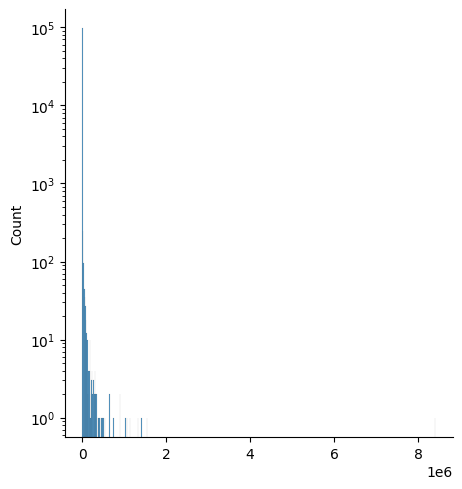

In [285]:
sns.displot(pCNFs_arr)
plt.yscale("log")
plt.show()

In [29]:
len(log_pCNFs), len(pCNFs)

(97385, 97385)

In [33]:
97385*47987*712

3327328364440

In [231]:
test_theta = val_dataset.X_data.data_df.to_numpy()[val_idx].squeeze()
jacobian_res = []
for t in tqdm(test_theta):
    # print(t)
    res = calc_jacobians_transform_cnf(t, val_dataset.X_data.transformations)
    assert np.abs(res) != np.inf
    jacobian_res.append(res)

jnp.sum(jnp.log(jnp.diag(val_dataset.X_data.L)))

100%|██████████| 97385/97385 [00:01<00:00, 64186.43it/s]


Array(-4.50417428, dtype=float64)

In [232]:
min(jacobian_res), max(jacobian_res)

(np.float64(-12.892340371933688), np.float64(10.591692799042908))

In [247]:
vmapped_jacobian_res = jax.vmap(calc_jacobians_transform_cnf_jit, in_axes=(0, None))(test_theta, tuple(val_dataset.X_data.transformations))

In [273]:
(val_dataset.X.shape[0],)

(97385,)

In [274]:
vmapped_jacobian_res.shape == (val_dataset.X.shape[0],)

True

In [250]:
np.allclose(vmapped_jacobian_res, np.array(jacobian_res))

True

In [175]:
far_sel  = val_dataset.y_data.data_df.to_numpy()[val_idx].squeeze() < 1

In [188]:
test_idx = 25
log_probs = flow.log_prob(theta[test_idx], condition = far[far_sel])
prob = np.sum(np.exp(log_probs))

In [189]:
prob, pCNFs[test_idx]

(np.float64(0.03229713220875751), np.float64(0.0322971322087575))

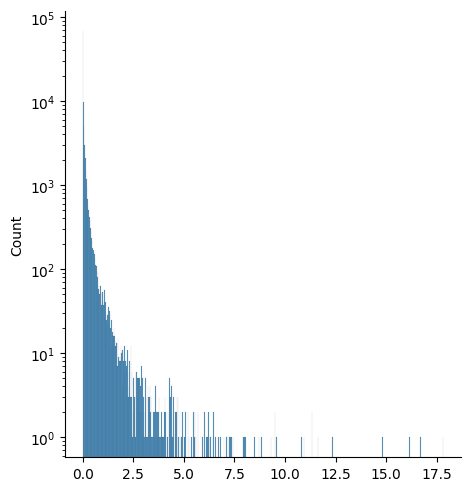

In [109]:
sns.displot(pCNFs)
plt.yscale("log")

In [114]:
p_model.min(), p_model.max()

(np.float64(1.3509063367596822e-16), np.float64(1.3607536440423128e-06))

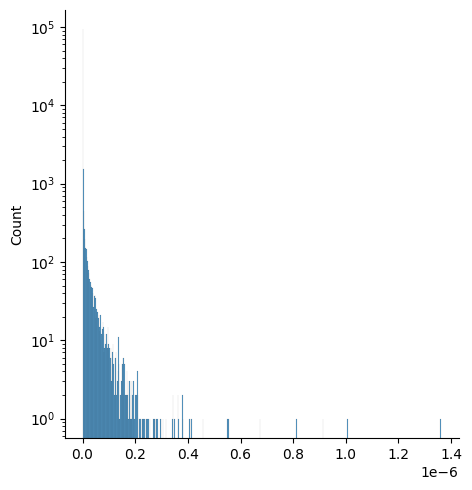

In [113]:
sns.displot(p_model)
plt.yscale("log")

In [147]:
n_total = len(train_dataset)
n_total**2/1e12

0.768190896225

In [191]:
val_dataset.X_data.transformations, dataset.X_data.transformations

(['log',
  'log',
  'log',
  'angle_pi',
  'angle_pi',
  'angle_signed_pi',
  'angle_pi',
  'angle_pi',
  'angle_pi',
  'angle_signed_pi',
  'angle_signed_pi',
  'angle_pi',
  'angle_signed_pi'],
 ['log',
  'log',
  'log',
  'angle_pi',
  'angle_pi',
  'angle_signed_pi',
  'angle_pi',
  'angle_pi',
  'angle_pi',
  'angle_signed_pi',
  'angle_signed_pi',
  'angle_pi',
  'angle_signed_pi'])

In [150]:
(pCNFs / p_model / n_total**2).max()

np.float64(1.188034550159676)

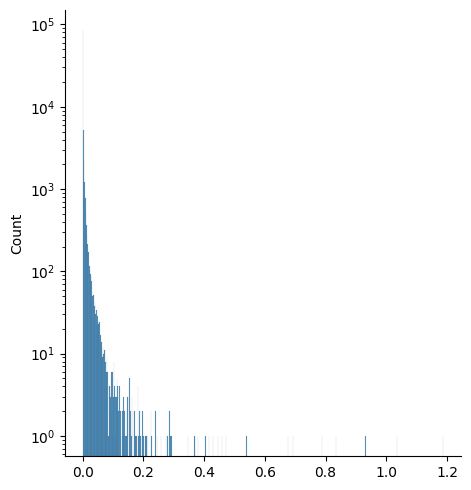

In [151]:
sns.displot(pCNFs / p_model / n_total**2)
plt.yscale("log")